<a href="https://colab.research.google.com/github/aleksandra20050404/Customer_Subscription_Prediction/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EDA.ipynb contains:

- Data Extraction
- Dataset Overview
- Missing values detection
- EDA
- Correlation analysis
- Feature Selection & Encoding
- Export Encoded Data


## Data Extraction

In [38]:
!pip install openml

In [39]:
import pandas as pd
import openml

# Download dataset by ID: 43718 from OpenML
dataset = openml.datasets.get_dataset(43718)

df, _, _, _ = dataset.get_data(dataset_format="dataframe", target=None)
print(df.head())


   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  


In [40]:
df.shape

(11162, 17)

- Instances: 11,162
- Features: 16 input variables
- Target (y): `deposit` – whether the client subscribed to a term deposit (yes or no)

## Dataset Overview
- Data types
- Missing values
- Duplicates

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  uint8 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  uint8 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  uint8 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  uint8 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(3), object(10), uint8(4)
memory usage: 1.1+ MB


### Missing values

In [42]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


- No missing values

### Duplicates

In [43]:

n_duplicates = df.duplicated().sum()
print(f"Duplicate rows: {n_duplicates}")

Duplicate rows: 0


## Data Preparation
- Separate features (`bank_data`) and target (`deposit`)

In [44]:
bank_data = df.drop(columns=['deposit'])
y = df['deposit']

**Exclude the `duration` column:**
The duration of a call is unknown until the call has ended, making it impossible to use for a predictive model that is supposed to target customers *before* the bank calls them (this would be data leakage).

In [45]:
bank_data = bank_data.drop(columns=['duration'])

**Create a binary feature for `pdays`:**
`pdays` = days since last contact, where `-1` means the client was never contacted before.

Created column **`was_contacted`**:
- `was_contacted = 1` → client had at least one previous contact
- `was_contacted = 0` → client had no previous contact

In [46]:

bank_data['was_contacted'] = (bank_data['pdays'] != -1).astype(int)
bank_data = bank_data.drop(columns=['pdays'])

**previous** (count of prior contacts) also overlaps with  "ever contacted" signal — previous = 0 , and lines up with pdays = -1 too. So dropping pdays cleans up the biggest redundancy, but importance for was_contacted and previous will still share some signal between them.

## EDA

### Check target distribution

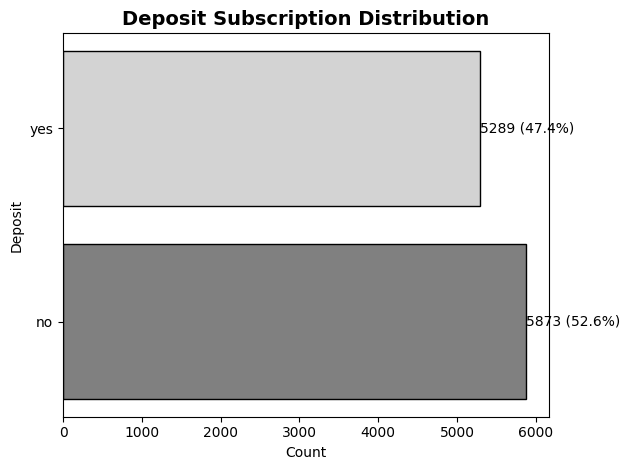

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

counts = y.value_counts()
plt.barh(counts.index, counts.values, color=['gray', 'lightgray'], edgecolor='black')
plt.title('Deposit Subscription Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Deposit')

for i, (bar, val) in enumerate(zip(plt.gca().patches, counts.values)):
    plt.text(val + 5, bar.get_y() + bar.get_height()/2,
             f'{val} ({val/len(y)*100:.1f}%)',
             va='center')

plt.tight_layout()
plt.show()

#### Balanced target distribution, no class imbalance.

### Visualize categorical columns

In [48]:
# Identify categorical columns
categorical = [col for col in bank_data.columns if bank_data[col].dtype == 'object']
df[categorical].head()

,job,marital,education,default,housing,loan,contact,month,poutcome
0,admin.,married,secondary,no,yes,no,unknown,may,unknown
1,admin.,married,secondary,no,no,no,unknown,may,unknown
2,technician,married,secondary,no,yes,no,unknown,may,unknown
3,services,married,secondary,no,yes,no,unknown,may,unknown
4,admin.,married,tertiary,no,no,no,unknown,may,unknown


In [49]:
# Check unique values for categorical columns
for col in categorical:
    uniques = bank_data[col].unique().tolist()
    print(f"{col}: {uniques}")

job: ['admin.', 'technician', 'services', 'management', 'retired', 'blue-collar', 'unemployed', 'entrepreneur', 'housemaid', 'unknown', 'self-employed', 'student']
marital: ['married', 'single', 'divorced']
education: ['secondary', 'tertiary', 'primary', 'unknown']
default: ['no', 'yes']
housing: ['yes', 'no']
loan: ['no', 'yes']
contact: ['unknown', 'cellular', 'telephone']
month: ['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'jan', 'feb', 'mar', 'apr', 'sep']
poutcome: ['unknown', 'other', 'failure', 'success']


### Visualize all categorical variables

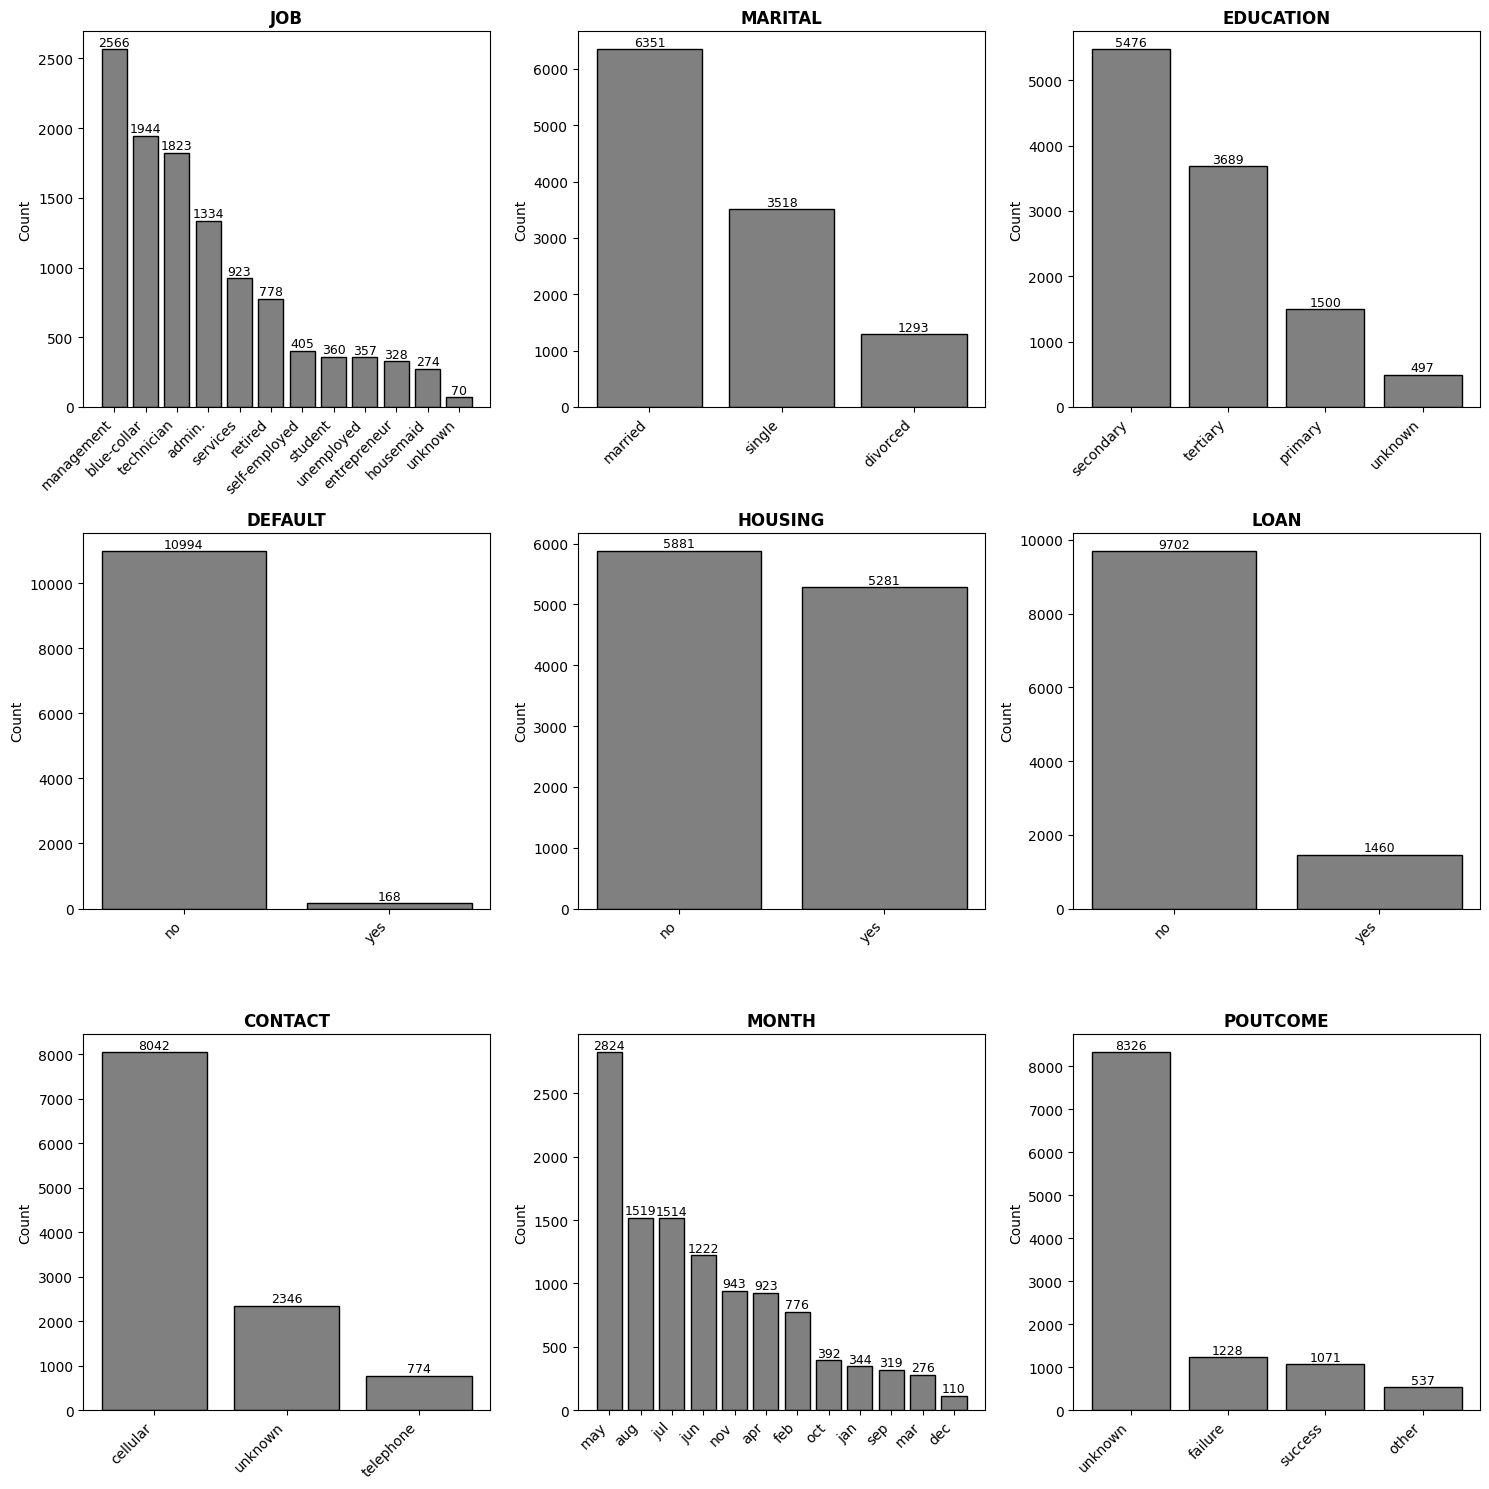

In [50]:
n_cols = len(categorical)
n_rows = (n_cols + 2) // 3  # Ceiling division

fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

for i, col in enumerate(categorical):
    counts = bank_data[col].value_counts()
    axes[i].bar(range(len(counts)), counts.values, color='gray', edgecolor='black')
    axes[i].set_xticks(range(len(counts)))
    axes[i].set_xticklabels(counts.index, rotation=45, ha='right')
    axes[i].set_title(col.upper(), fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Count')

    for bar, val in zip(axes[i].patches, counts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                    str(val), ha='center', va='bottom', fontsize=9)

for i in range(len(categorical), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

#### Imbalance effects:

**default** - check its feature importance/coefficient after fitting (should be near 0) Any pattern the model finds for "clients who've defaulted before"  is being estimated from a very small sample, so it's inherently noisy — a logistic regression coefficient on default_yes will have a wide confidence interval, and a tree split on it is prone to overfitting

**loan** - moderate, more workable imbalance.

**month** -  Uneven sample sizes across months — May alone is 2,824 rows (~25% of the data) while Dec is only 110. Whatever pattern the model learns for December is estimated from a tiny sample and will be noisier/less reliable than the May pattern.
Generalization risk — if May's low conversion (or whichever month stands out) reflects something specific to that historical campaign wave rather than an inherent property of May, the model may not transfer as well to a future campaign run in a different year. Worth flagging as a limitation, not a reason to remove the feature.

### Visualize numerical features with the target

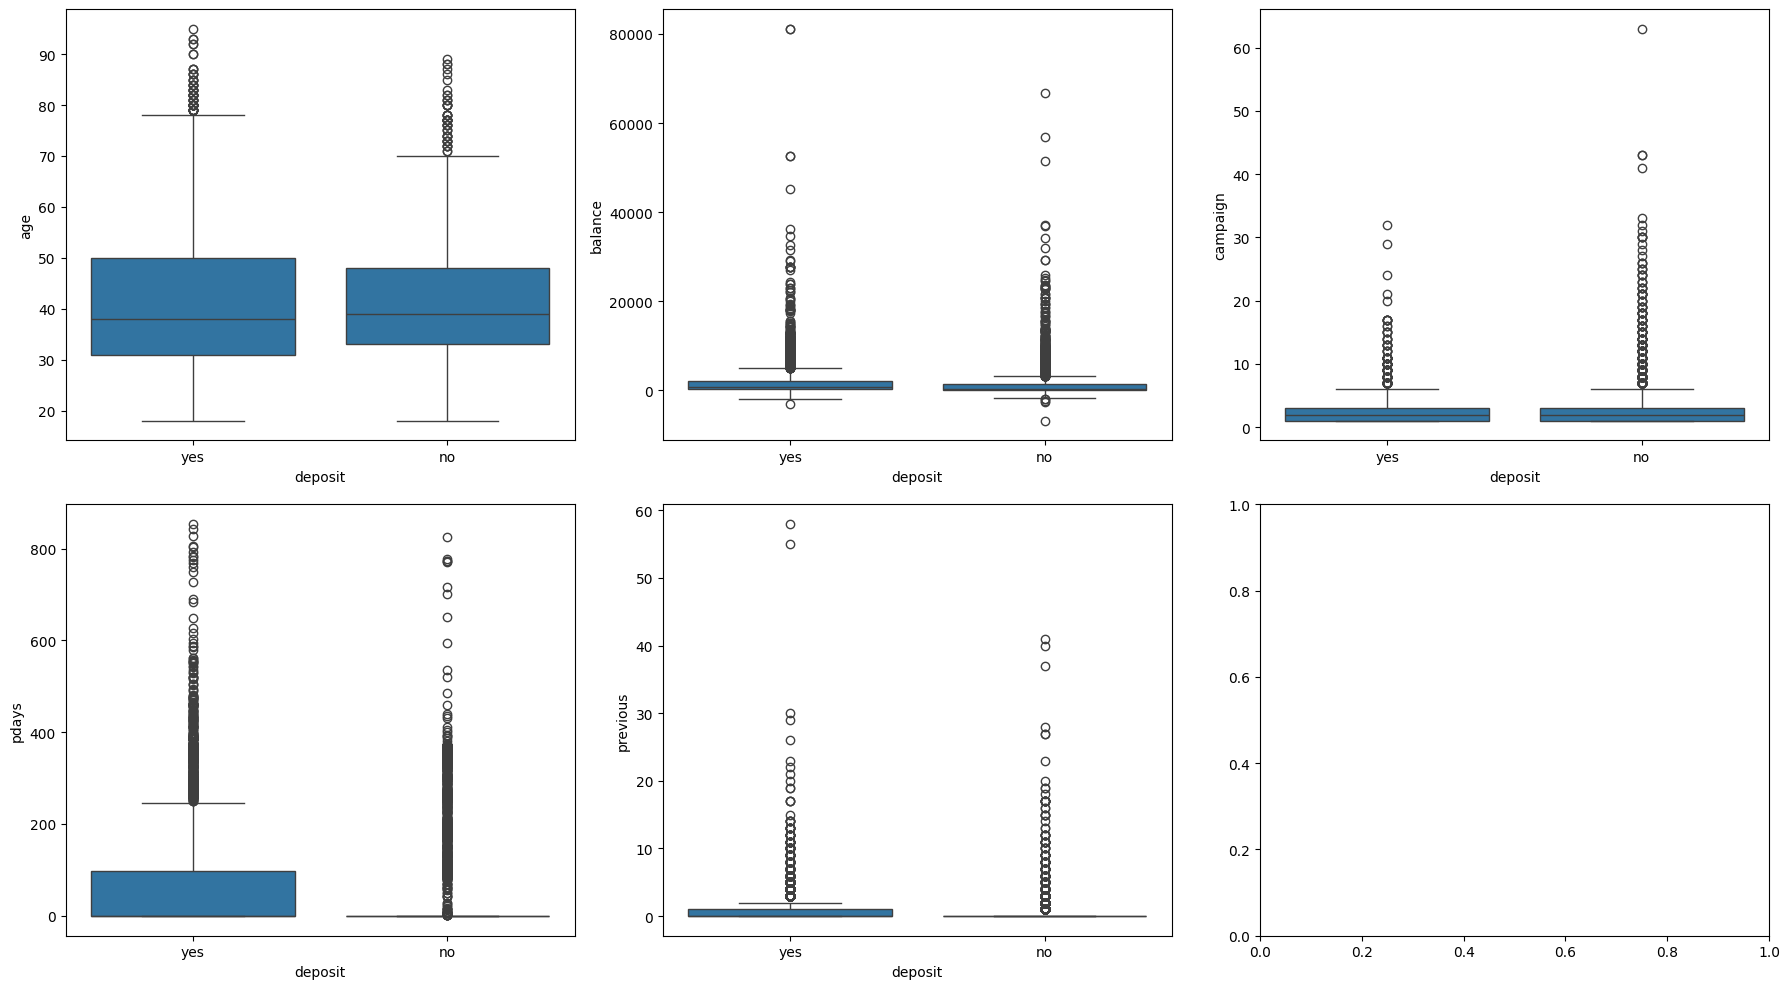

In [51]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
numerical_cols = ['age', 'balance', 'campaign', 'pdays', 'previous']

for i, col in enumerate(numerical_cols):
    row, col_idx = i // 3, i % 3
    sns.boxplot(x='deposit', y=col, data=df, ax=axes[row, col_idx])

plt.tight_layout()

plt.show()

### Interpretation:

**campaign:** both groups cluster at low contact counts (median ~2–3) with a long tail of outliers (up to 30+ calls). No clear separation by median — but this is exactly the "contact fatigue" pattern worth naming even though the box itself doesn't show it strongly.

**pdays:** this is the most visually distinct boxplot of the five — subscribers ("yes") have a visibly higher box (up to ~100 days) while non-subscribers are compressed near 0. This is the clearest numeric signal in the set, and it reinforces the poutcome/was_contacted conclusion: clients contacted before are more likely to subscribe now.

**previous:** same direction as pdays but weaker — "yes" sits slightly higher than "no," both with heavy outlier tails.

## Correlation Analysis

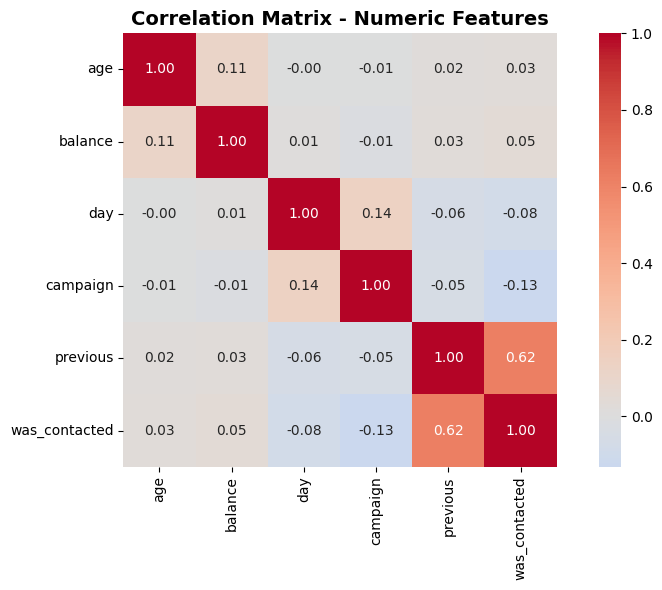

,age,balance,day,campaign,previous,was_contacted
age,1.000000,0.112300,-0.000762,-0.005278,0.020169,0.027093
balance,0.112300,1.000000,0.010467,-0.013894,0.030805,0.046107
day,-0.000762,0.010467,1.000000,0.137007,-0.058981,-0.082697
campaign,-0.005278,-0.013894,0.137007,1.000000,-0.049699,-0.131363
previous,0.020169,0.030805,-0.058981,-0.049699,1.000000,0.622124
was_contacted,0.027093,0.046107,-0.082697,-0.131363,0.622124,1.000000


In [52]:

numeric_for_corr = ['age', 'balance', 'day', 'campaign', 'previous', 'was_contacted']

plt.figure(figsize=(9, 6))
corr = bank_data[numeric_for_corr].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix - Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
corr

**previous and was_contacted:** 0.62 — moderate-strong.

This is the redundancy, features measuring overlapping information. Confirms that feature-importance credit for these features will be split rather than cleanly attributed to one.

**day and campaign:** 0.14 — weak.

Contacts made later in the month tend to involve slightly more calls in this campaign, but it's too weak to act on.

**campaign and  was_contacted:** -0.13 — weak negative.

Clients with a history from a previous campaign get slightly fewer contacts in this one — plausible (maybe reps de-prioritize repeat calls once they've already made contact), but weak.

**age and balance: 0.11** — weak positive.

Older clients, somewhat higher balances but too small to call meaningful.
Everything else (age/day, age/campaign, balance/campaign, balance/previous, day/was_contacted, etc.) sits at ±0.08 or below — essentially no linear relationship.

## Preprocessing and Encoding

### Encoding Strategy :

 ColumnTransformer applies:
## One-hot encoding
 - nominal features (job, marital status, default, housing, loan, contact type, month, previous outcome)

## Ordinal encoding
- **education**:
1. Record an explicit "education_unknown" indicator flag.
2. Impute 'unknown' with the most frequent *known* category before ordinal encoding, so the ordinal scale only ever reflects primary < secondary < tertiary.


- **pdays**
pdays = -1 means "never contacted" - a sentinel, not a real distance. Since
was_contacted already captures that signal as a clean binary flag, drop
the raw pdays column from the numeric features.

## Standard scaling
-  numeric features (age, balance, day, campaign, pdays, previous)


## Cyclical encoding for 'day'
- **day-of-month** wraps around (day 31 is close to day 1, not far from it), so
treating it as a plain scaled numeric feature is misleading. Replace it with sine/cosine components on a 31-day cycle

 Transfmer was fit only on the training set and reused to transform the test set, avoiding data leakage. It's saved to preprocessor.pkl so new data can be encoded identically at inference time.


In [53]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


bank_data['education_unknown'] = (bank_data['education'] == 'unknown').astype(int)
education_mode = bank_data.loc[bank_data['education'] != 'unknown', 'education'].mode()[0]
bank_data['education'] = bank_data['education'].replace('unknown', education_mode)

# clical encoding for 'day'
bank_data['day_sin'] = np.sin(2 * np.pi * bank_data['day'] / 31)
bank_data['day_cos'] = np.cos(2 * np.pi * bank_data['day'] / 31)
bank_data = bank_data.drop(columns=['day'])

# 1. Feature groups
nominal_features   = ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
ordinal_features   = ['education']  # primary < secondary < tertiary (unknown imputed above)
numeric_features   = ['age', 'balance', 'campaign', 'previous', 'day_sin', 'day_cos']  # day replaced by its cyclical form

# 2. Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        # One-Hot Encoding for nominal features (including poutcome)
        ('nominal', OneHotEncoder(
            sparse_output=False,
            handle_unknown='ignore'
        ), nominal_features),

        # Ordinal Encoding for education (unknown already imputed above)
        ('ordinal', OrdinalEncoder(
            categories=[['primary', 'secondary', 'tertiary']]
        ), ordinal_features),

        # Standardize numerical features (including the two cyclical day columns)
        ('numerical', StandardScaler(), numeric_features)
    ],
    remainder='passthrough'  # keeps was_contacted and education_unknown as-is
)

#### Train-test split

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    bank_data, y, test_size=0.3, random_state=42, stratify=y)

#### Fit and Transform

In [55]:
# Fit on training data only
X_train_encoded = preprocessor.fit_transform(X_train)

# Transform test data
X_test_encoded = preprocessor.transform(X_test)

# Get feature names
feature_names = preprocessor.get_feature_names_out()
feature_names

array(['nominal__job_admin.', 'nominal__job_blue-collar',
       'nominal__job_entrepreneur', 'nominal__job_housemaid',
       'nominal__job_management', 'nominal__job_retired',
       'nominal__job_self-employed', 'nominal__job_services',
       'nominal__job_student', 'nominal__job_technician',
       'nominal__job_unemployed', 'nominal__job_unknown',
       'nominal__marital_divorced', 'nominal__marital_married',
       'nominal__marital_single', 'nominal__default_no',
       'nominal__default_yes', 'nominal__housing_no',
       'nominal__housing_yes', 'nominal__loan_no', 'nominal__loan_yes',
       'nominal__contact_cellular', 'nominal__contact_telephone',
       'nominal__contact_unknown', 'nominal__month_apr',
       'nominal__month_aug', 'nominal__month_dec', 'nominal__month_feb',
       'nominal__month_jan', 'nominal__month_jul', 'nominal__month_jun',
       'nominal__month_mar', 'nominal__month_may', 'nominal__month_nov',
       'nominal__month_oct', 'nominal__month_sep',
    

In [56]:
X_train_df = pd.DataFrame(X_train_encoded, columns=feature_names)
X_test_df = pd.DataFrame(X_test_encoded, columns=feature_names)

print(f"Training shape: {X_train_df.shape}")
print(f"Test shape: {X_test_df.shape}")
print(f"Features: {len(feature_names)}")

Training shape: (7813, 49)
Test shape: (3349, 49)
Features: 49


- 7,813 training samples
- 3,349 test samples

## Export Encoded Data

In [57]:
import os
import joblib

from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/Telemarketing'  # update to your folder

os.makedirs(f'{DATA_PATH}/data/processed', exist_ok=True)
os.makedirs(f'{DATA_PATH}/models', exist_ok=True)

# Save training/test data
X_train_df.to_csv(f'{DATA_PATH}/data/processed/X_train_encoded.csv', index=False)
X_test_df.to_csv(f'{DATA_PATH}/data/processed/X_test_encoded.csv', index=False)

# Save target variables
y_train.to_csv(f'{DATA_PATH}/data/processed/y_train.csv', index=False)
y_test.to_csv(f'{DATA_PATH}/data/processed/y_test.csv', index=False)

# Save preprocessor for later use
joblib.dump(preprocessor, f'{DATA_PATH}/models/preprocessor.pkl')

print(f"Saved encoded data and preprocessor under {DATA_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved encoded data and preprocessor under /content/drive/MyDrive/Telemarketing


In [58]:
import os

# Check the same DATA_PATH used for saving above (fixed typo: "Telemarketingn" -> your real folder)
print(f"Checking folder: {DATA_PATH}")

if os.path.exists(DATA_PATH):
    print("\nCurrent files:")
    for root, dirs, files in os.walk(DATA_PATH):
        for f in files:
            full_path = os.path.join(root, f)
            size = os.path.getsize(full_path)
            rel_path = os.path.relpath(full_path, DATA_PATH)
            print(f"  {rel_path} ({size:,} bytes)")
else:
    print("Folder does not exist yet — it will be created when you save data to it.")

Checking folder: /content/drive/MyDrive/Telemarketing

Current files:
  models_1.ipynb (17,464 bytes)
  EDA_1.ipynb (476,351 bytes)
  data/processed/X_train_encoded.csv (2,270,219 bytes)
  data/processed/X_test_encoded.csv (973,636 bytes)
  data/processed/y_train.csv (27,149 bytes)
  data/processed/y_test.csv (11,642 bytes)
  models/preprocessor.pkl (6,034 bytes)
